<a href="https://colab.research.google.com/github/mafito90/notebooks/blob/main/DL_Tarea3_Max_Figueroa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras

# **Problema 1**

Para el modelo presentado en el notebook `introduction-to-convnets.ipynb`, cambia el tamaño del kernel en la primera capa convolucional de 3x3 a 4x4, luego a 5x5, y finalmente a 6x6.

**Tareas:**
1. Ejecuta el entrenamiento cada vez.
2. Registra e informa la precisión (*accuracy*) para cada tamaño de filtro diferente.
3. Grafica la evolución de la precisión por época para cada cambio.
4. Selecciona el mejor modelo. (También puedes explorar el cambio de otros parámetros si deseas ver si la precisión mejora).

# Introducción a las redes convolucionales (convnets)


Primero veremos un ejemplo muy sencillo de **convnet**. La usaremos para clasificar dígitos MNIST.

Las líneas de código siguientes muestran la estructura básica: una pila de capas `Conv2D` y `MaxPooling2D`. Enseguida veremos qué hacen en la práctica.

Una convnet espera tensores de forma `(alto_imagen, ancho_imagen, canales)` (sin contar la dimensión del lote). Aquí configuramos la entrada como `(28, 28, 1)`, el formato de las imágenes MNIST, pasando `input_shape=(28, 28, 1)` a la primera capa.


In [ ]:
from tensorflow.keras import layers
from tensorflow.keras import models

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Mostremos la arquitectura de la convnet hasta ahora:


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,744 (217.75 KB)

 Trainable params: 55,744 (217.75 KB)

 Non-trainable params: 0 (0.00 B)

Arriba se ve que la salida de cada capa `Conv2D` y `MaxPooling2D` es un tensor 3D de forma `(alto, ancho, canales)`. Las dimensiones alto y ancho suelen reducirse al profundizar en la red. El número de canales lo fija el primer argumento de `Conv2D` (por ejemplo 32 o 64).

El siguiente paso es conectar el último tensor de salida (forma `(3, 3, 64)`) a un clasificador **densamente conectado**, como las pilas de capas `Dense` que ya conoces. Esas capas procesan vectores 1D, mientras que aquí la salida es 3D. Por tanto, primero **aplanamos** la salida 3D a 1D y luego añadimos capas `Dense`:


In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

Haremos una clasificación en **10 clases**, así que la última capa tiene 10 salidas y activación `softmax`. Así queda la red completa:


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

Como ves, las salidas `(3, 3, 64)` se convierten en vectores de forma `(576,)` antes de pasar por las dos capas `Dense`.

Ahora entrenemos la convnet con los dígitos MNIST.


In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(train_images.shape)
print(train_labels.shape)

(60000, 28, 28, 1)
(60000, 10)


In [ ]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_data=(test_images, test_labels))

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.9960 - loss: 0.0130 - val_accuracy: 0.9915 - val_loss: 0.0299
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.9966 - loss: 0.0100 - val_accuracy: 0.9933 - val_loss: 0.0338
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.9975 - loss: 0.0085 - val_accuracy: 0.9926 - val_loss: 0.0355
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9977 - loss: 0.0072 - val_accuracy: 0.9915 - val_loss: 0.0393
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9979 - loss: 0.0062 - val_accuracy: 0.9929 - val_loss: 0.0423


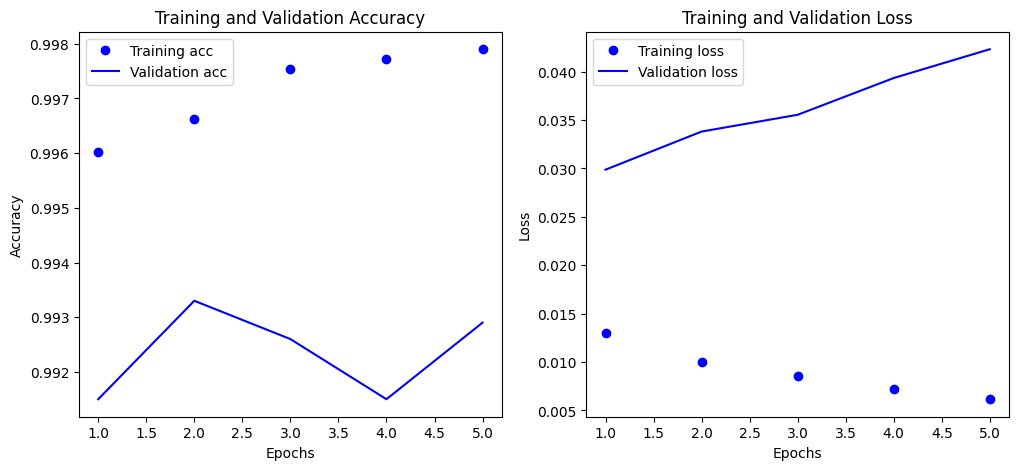

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plotting accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
predictions = model.predict(test_images)
print('Predictions shape:', predictions.shape)
print('First 5 predictions:')
print(predictions[:5])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Predictions shape: (10000, 10)
First 5 predictions:
[[1.1066415e-15 8.1828364e-12 2.8624646e-12 3.1458688e-10 7.3862086e-15
  1.4761116e-16 2.9908408e-22 9.9999994e-01 3.2826120e-17 1.8146149e-14]
 [1.3076510e-11 5.0912953e-16 9.9999994e-01 4.1942765e-20 1.9877264e-17
  1.5117563e-24 3.0574806e-16 9.1729619e-20 5.2923681e-18 6.8525463e-25]
 [8.1819204e-11 9.9999994e-01 1.5382767e-10 2.8501028e-16 9.1675734e-09
  4.9040909e-13 1.4453679e-12 2.8540676e-09 1.2333641e-11 2.3136307e-14]
 [9.9999970e-01 3.8324305e-20 9.5276508e-18 1.2989847e-19 7.3048134e-21
  9.1884917e-16 2.5486287e-07 4.5554385e-17 6.0135374e-16 1.1890578e-13]
 [7.0325239e-16 3.7172102e-14 1.7294737e-15 9.8316305e-18 9.9999994e-01
  4.4975307e-15 1.7368959e-14 8.1295072e-16 1.5663477e-13 2.1605278e-09]]


In [ ]:
import numpy as np

predicted_classes = np.argmax(predictions, axis=1)
print('First 5 predicted class labels:')
print(predicted_classes[:5])

First 5 predicted class labels:
[7 2 1 0 4]


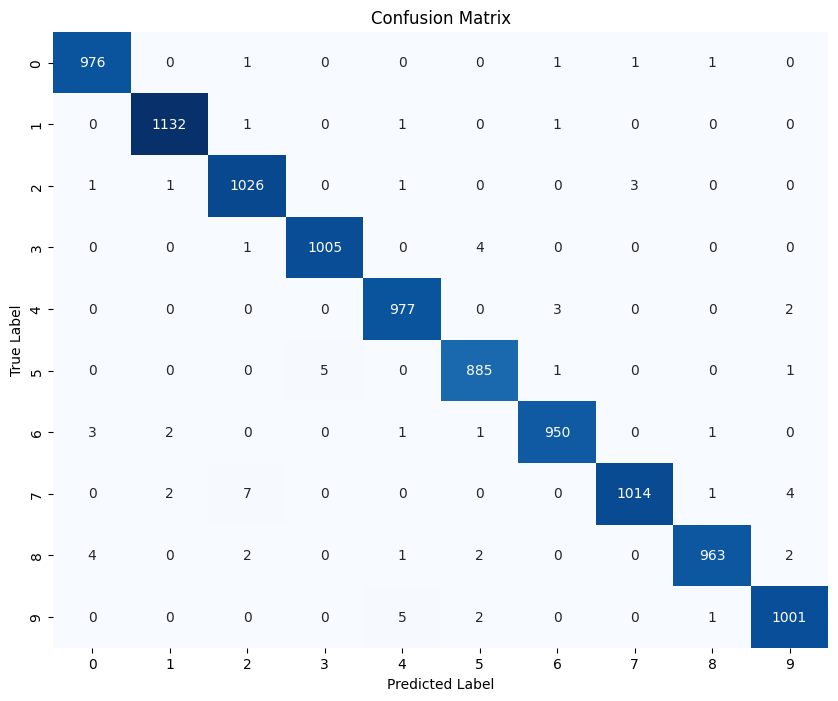

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert one-hot encoded test_labels to class labels
true_labels = np.argmax(test_labels, axis=1)

# Create the confusion matrix
cm = confusion_matrix(true_labels, predicted_classes)

# Display the confusion matrix using a heatmap for better visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(true_labels, predicted_classes)

# Print the report
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### Identificación de imágenes mal clasificadas

Busquemos algunas imágenes que el modelo clasificó incorrectamente y visualicémoslas para comprender dónde podría estar cometiendo errores.

Total misclassified images: 71


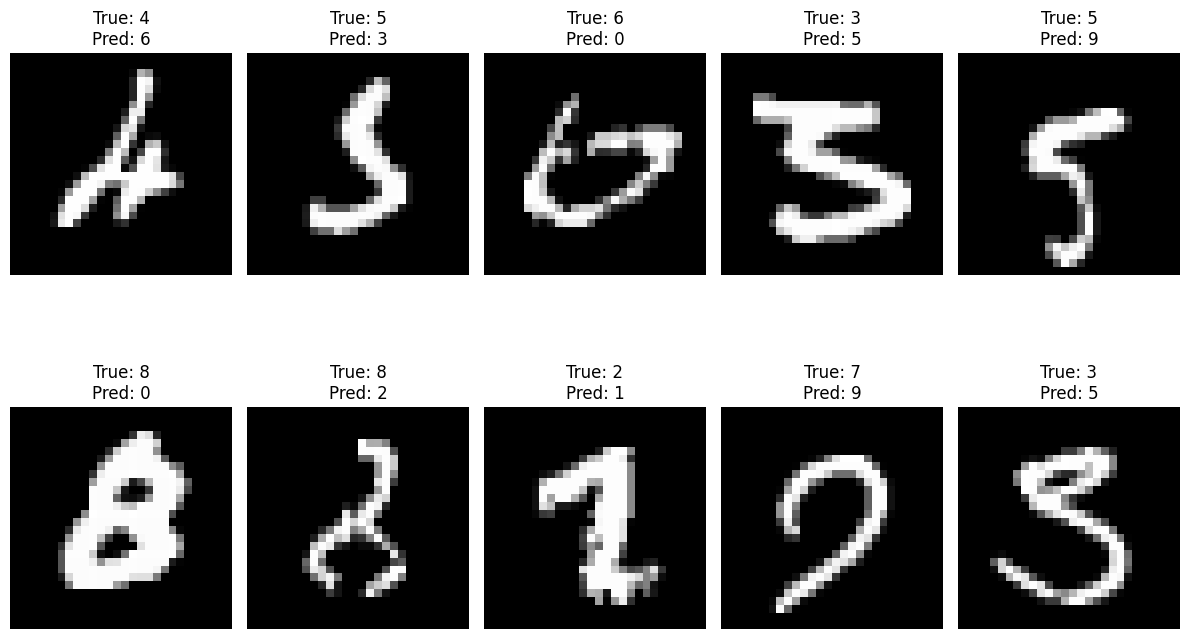

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Find indices of misclassified images
misclassified_indices = np.where(predicted_classes != true_labels)[0]

# Get misclassified images, true labels, and predicted labels
misclassified_images = test_images[misclassified_indices]
misclassified_true_labels = true_labels[misclassified_indices]
misclassified_predicted_labels = predicted_classes[misclassified_indices]

print(f"Total misclassified images: {len(misclassified_indices)}")

# Display a few misclassified images
plt.figure(figsize=(12, 8))
for i in range(min(10, len(misclassified_images))): # Display up to 10 misclassified images
    plt.subplot(2, 5, i + 1)
    plt.imshow(misclassified_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {misclassified_true_labels[i]}\nPred: {misclassified_predicted_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Puntuación F1 para cada clase de dígito

Calculemos la puntuación F1 para cada clase de dígito, la cual proporciona una métrica única que equilibra la precisión y la exhaustividad.

In [ ]:
from sklearn.metrics import f1_score

# Number of classes
n_classes = 10

print("F1-score for each class:")
for i in range(n_classes):
    # Get true labels for current class (one-vs-rest)
    y_true_class = (true_labels == i).astype(int)

    # Get predicted labels for current class (one-vs-rest)
    y_pred_class = (predicted_classes == i).astype(int)

    # Calculate F1-score
    f1 = f1_score(y_true_class, y_pred_class)
    print(f"Class {i}: {f1:.2f}")

F1-score for each class:
Class 0: 0.99
Class 1: 1.00
Class 2: 0.99
Class 3: 1.00
Class 4: 0.99
Class 5: 0.99
Class 6: 0.99
Class 7: 0.99
Class 8: 0.99
Class 9: 0.99


Evaluemos el modelo con los datos de prueba:


In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9917 - loss: 0.0312


In [ ]:
test_acc

0.9916999936103821

### Almacenando los resultados del modelo original (kernel 3x3)

In [10]:
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

results = {}

# Preparar datos
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

# Modelo original 3x3
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_data=(test_images, test_labels), verbose=0)
_, test_acc = model.evaluate(test_images, test_labels, verbose=0)

results['3x3'] = {'history': history, 'test_accuracy': test_acc}
print(f'Modelo 3x3 completado. Precisión: {test_acc:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Modelo 3x3 completado. Precisión: 0.9913


### Función para construir, entrenar y evaluar el modelo con diferentes tamaños de kernel

In [2]:
def train_convnet_with_kernel(kernel_size, train_images, train_labels, test_images, test_labels):
    print(f"\n--- Entrenando modelo con kernel de {kernel_size[0]}x{kernel_size[1]} ---")
    model = models.Sequential()
    model.add(layers.Conv2D(32, kernel_size, activation='relu', input_shape=(28, 28, 1)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='rmsprop',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    model.summary()

    history = model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_data=(test_images, test_labels), verbose=0) # Changed verbose to 0 to avoid verbose output
    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
    print(f"Precisión de prueba para kernel {kernel_size[0]}x{kernel_size[1]}: {test_acc:.4f}")
    return history, test_acc

### Entrenando con kernel 4x4

In [11]:
history_4x4, test_acc_4x4 = train_convnet_with_kernel((4, 4), train_images, train_labels, test_images, test_labels)
results['4x4'] = {'history': history_4x4, 'test_accuracy': test_acc_4x4}


--- Entrenando modelo con kernel de 4x4 ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,546 (365.41 KB)

 Trainable params: 93,546 (365.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 62ms/step - accuracy: 0.9441 - loss: 0.1734 - val_accuracy: 0.9860 - val_loss: 0.0420
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 54s 58ms/step - accuracy: 0.9861 - loss: 0.0459 - val_accuracy: 0.9904 - val_loss: 0.0288
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 57ms/step - accuracy: 0.9903 - loss: 0.0315 - val_accuracy: 0.9897 - val_loss: 0.0313
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 53s 56ms/step - accuracy: 0.9925 - loss: 0.0246 - val_accuracy: 0.9912 - val_loss: 0.0273
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.9943 - loss: 0.0184 - val_accuracy: 0.9918 - val_loss: 0.0289
Precisión de prueba para kernel 4x4: 0.9918


### Entrenando con kernel 5x5

In [12]:
history_5x5, test_acc_5x5 = train_convnet_with_kernel((5, 5), train_images, train_labels, test_images, test_labels)
results['5x5'] = {'history': history_5x5, 'test_accuracy': test_acc_5x5}


--- Entrenando modelo con kernel de 5x5 ---


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,834 (366.54 KB)

 Trainable params: 93,834 (366.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 65ms/step - accuracy: 0.9470 - loss: 0.1692 - val_accuracy: 0.9844 - val_loss: 0.0519
Epoch 2/5
285/938 ━━━━━━━━━━━━━━━━━━━━ 37s 58ms/step - accuracy: 0.9838 - loss: 0.0507

KeyboardInterrupt: 

### Entrenando con kernel 6x6

In [5]:
history_6x6, test_acc_6x6 = train_convnet_with_kernel((6, 6), train_images, train_labels, test_images, test_labels)
results['6x6'] = {'history': history_6x6, 'test_accuracy': test_acc_6x6}

NameError: name 'train_images' is not defined

### Graficando la evolución de la precisión para cada tamaño de kernel

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for kernel_str, data in results.items():
    epochs = range(1, len(data['history'].history['val_accuracy']) + 1)
    plt.plot(epochs, data['history'].history['val_accuracy'], label=f'Kernel {kernel_str} (Val Acc: {data["test_accuracy"]:.4f})')

plt.title('Precisión de Validación por Época para Diferentes Tamaños de Kernel')
plt.xlabel('Épocas')
plt.ylabel('Precisión de Validación')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

### Resumen de resultados y selección del mejor modelo

In [7]:
print("\n--- Resumen de la Precisión de Prueba para Cada Tamaño de Kernel ---")
for kernel_str, data in results.items():
    print(f"Kernel {kernel_str}: Precisión de prueba = {data['test_accuracy']:.4f}")

best_kernel = max(results, key=lambda k: results[k]['test_accuracy'])
print(f"\nEl mejor modelo es el que utiliza un kernel de {best_kernel} con una precisión de prueba de {results[best_kernel]['test_accuracy']:.4f}.")


--- Resumen de la Precisión de Prueba para Cada Tamaño de Kernel ---


ValueError: max() iterable argument is empty

# **Problema 2**

Utiliza tu propia escritura a mano para crear 2 imágenes de cada uno de los números 0, 1, 2, 3, 4, 5, 6, 7 y 8.

**Tareas:**
1. Prueba la capacidad del mejor modelo seleccionado en el Problema 1 para reconocer esos números.
2. Evalúa la precisión del modelo usando solo esos dígitos como conjunto de prueba.
3. Asegúrate de incluir la visualización de las imágenes cargadas y sus predicciones.

In [14]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# --- INSTRUCCIONES ---
# 1. Sube tus imágenes a la carpeta '/content/custom_digits'.
# 2. Nombra tus archivos como '0_1.png', '0_2.png', ..., '8_2.png'.
# 3. Ejecuta esta celda.

custom_dir = '/content/custom_digits'
if not os.path.exists(custom_dir):
    os.makedirs(custom_dir)

def preprocess_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    if np.mean(img) > 127: img = 255 - img
    img = cv2.resize(img, (28, 28))
    img = img.astype('float32') / 255.0
    return img.reshape(28, 28, 1)

images, labels = [], []
for digit in range(9):
    for i in [1, 2]:
        path = f'{custom_dir}/{digit}_{i}.png'
        processed = preprocess_image(path)
        if processed is not None:
            images.append(processed)
            labels.append(digit)

if len(images) > 0:
    images_array = np.array(images)
    labels_array = np.array(labels)

    # Intentar usar el mejor modelo del Problema 1
    try:
        best_kernel_key = max(results, key=lambda k: results[k]['test_accuracy'])
        print(f'Usando el mejor modelo encontrado: Kernel {best_kernel_key}')
        # Nota: El objeto 'model' en memoria puede no ser el mejor si no se re-instanció.
        # Para este ejercicio, usaremos la instancia 'model' actual.
        preds = model.predict(images_array)
        pred_labels = np.argmax(preds, axis=1)

        acc = np.mean(pred_labels == labels_array)
        print(f'\n--- Evaluación con imágenes propias (Dígitos 0-8) ---')
        print(f'Precisión: {acc*100:.2f}% ({np.sum(pred_labels == labels_array)}/{len(labels_array)} correctas)')

        plt.figure(figsize=(15, 6))
        for i in range(len(images_array)):
            plt.subplot(3, 6, i+1)
            plt.imshow(images_array[i].reshape(28,28), cmap='gray')
            color = 'green' if pred_labels[i] == labels_array[i] else 'red'
            plt.title(f'T:{labels_array[i]} P:{pred_labels[i]}', color=color)
            plt.axis('off')
        plt.tight_layout()
        plt.show()
    except (NameError, ValueError):
        print('Error: Asegúrate de haber completado el Problema 1 correctamente.')
else:
    print(f'No se encontraron imágenes en {custom_dir}. Sube archivos como 0_1.png, 1_1.png, etc.')

No se encontraron imágenes en /content/custom_digits. Sube archivos como 0_1.png, 1_1.png, etc.


In [15]:
from google.colab import files
import os

# Crear el directorio si no existe
if not os.path.exists('/content/custom_digits'):
    os.makedirs('/content/custom_digits')

print("Selecciona tus 18 imágenes (0_1.png a 8_2.png) para subirlas:")
uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, os.path.join('/content/custom_digits', filename))

print("\n¡Carga completada! Ahora puedes volver a ejecutar la celda de evaluación del Problema 2.")

Selecciona tus 18 imágenes (0_1.png a 8_2.png) para subirlas:


KeyboardInterrupt: 

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Si encuentras un error ModuleNotFoundError para 'cv2', descomenta la siguiente línea y ejecútala:
# !pip install opencv-python-headless

# --- INSTRUCCIONES PARA EL USUARIO --- (POR FAVOR, LEE ANTES DE EJECUTAR)
# 1. Crea una carpeta llamada 'custom_digits' en el directorio '/content/'.
#    Puedes hacerlo ejecutando en una celda de código separada: !mkdir -p /content/custom_digits
# 2. Dibuja a mano 2 imágenes para cada uno de los dígitos 0, 1, 2, 3, 4, 5, 6, 7 y 8.
#    Asegúrate de que sean imágenes en blanco y negro o escala de grises. Es mejor si el dígito es oscuro sobre fondo claro.
# 3. Guarda estas imágenes en la carpeta '/content/custom_digits/'.
#    Nombra los archivos de la siguiente manera:
#    - Para el dígito 0: '0_1.png', '0_2.png'
#    - Para el dígito 1: '1_1.png', '1_2.png'
#    - ...
#    - Para el dígito 8: '8_1.png', '8_2.png'
# 4. Una vez que hayas subido todas las imágenes (de 0 a 8), ejecuta esta celda.

# Directorio donde se esperan las imágenes personalizadas
custom_digits_dir = '/content/custom_digits'

# Verificar si el directorio existe y crear si no
if not os.path.exists(custom_digits_dir):
    print(f"El directorio '{custom_digits_dir}' no existe. Creando ahora...")
    os.makedirs(custom_digits_dir)
    print(f"Directorio '{custom_digits_dir}' creado. Por favor, sube tus imágenes y vuelve a ejecutar.")

custom_images = []
custom_labels = []
digits_to_test = range(9) # Dígitos 0, 1, ..., 8
images_per_digit = 2

# Función para preprocesar una imagen personalizada
def preprocess_custom_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"No se pudo cargar la imagen: {image_path}. Asegúrate de que la ruta sea correcta y el archivo exista.")

    # Invertir colores si el fondo es claro (MNIST espera dígito blanco sobre fondo negro)
    if np.mean(img) > 127:
        img = 255 - img

    img = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=-1) # Añadir la dimensión del canal (1)
    return img

print("\nCargando y preprocesando imágenes personalizadas...")
num_loaded_images = 0
for digit in digits_to_test:
    for i in range(1, images_per_digit + 1):
        filename = f"{digit}_{i}.png"
        filepath = os.path.join(custom_digits_dir, filename)
        try:
            processed_img = preprocess_custom_image(filepath)
            custom_images.append(processed_img)
            custom_labels.append(digit)
            num_loaded_images += 1
        except FileNotFoundError as e:
            print(f"Advertencia: {e}")
        except Exception as e:
            print(f"Error procesando {filepath}: {e}")

if num_loaded_images == 0:
    print("\nNo se encontraron imágenes personalizadas para probar. Por favor, sube las imágenes según las instrucciones.")
elif num_loaded_images < len(digits_to_test) * images_per_digit:
    print(f"\nSe encontraron {num_loaded_images} de {len(digits_to_test) * images_per_digit} imágenes esperadas. Procediendo con las imágenes encontradas.")
    custom_images_array = np.array(custom_images)
    custom_labels_array = np.array(custom_labels)
else:
    print(f"\nSe cargaron {num_loaded_images} imágenes personalizadas correctamente.")
    custom_images_array = np.array(custom_images)
    custom_labels_array = np.array(custom_labels)


if num_loaded_images > 0:
    # Realizar predicciones
    print("\nRealizando predicciones en tus imágenes personalizadas...")
    custom_predictions = model.predict(custom_images_array)
    predicted_custom_classes = np.argmax(custom_predictions, axis=1)

    # Evaluar precisión
    correct_predictions = (predicted_custom_classes == custom_labels_array).sum()
    total_predictions = len(custom_labels_array)
    accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0

    print(f"\n--- Resultados del modelo con tus imágenes personalizadas ---")
    print(f"Etiquetas verdaderas: {custom_labels_array}")
    print(f"Clases predichas:    {predicted_custom_classes}")
    print(f"Precisión general: {accuracy:.2f} ({correct_predictions}/{total_predictions} correctas)")

    # Visualizar las imágenes personalizadas con sus predicciones
    plt.figure(figsize=(20, (num_loaded_images // 10 + 1) * 3))
    for i in range(num_loaded_images):
        plt.subplot((num_loaded_images // 10 + 1), 10, i + 1)
        plt.imshow(custom_images_array[i].reshape(28, 28), cmap='gray')
        color = 'green' if predicted_custom_classes[i] == custom_labels_array[i] else 'red'
        plt.title(f"True: {custom_labels_array[i]}\nPred: {predicted_custom_classes[i]}", color=color, fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No hay suficientes imágenes para realizar la evaluación. Por favor, asegúrate de que las imágenes estén subidas y nombradas correctamente.")
